In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load data
car = pd.read_csv('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Textbook Dataset/ALL CSV FILES - 2nd Edition/Carseats.csv')

# One-hot encode categoricals for tree models
car_enc = pd.get_dummies(car, columns=["ShelveLoc", "Urban", "US"], drop_first=True)

X = car_enc.drop(columns=["Sales"])
y = car_enc["Sales"]

# (a) Train/test split: 200 train, 200 test (like ISLR)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=200, random_state=1
)


(b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

In [2]:
tree = DecisionTreeRegressor(random_state=1)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
print("Unpruned tree test MSE:", mse_tree)


Unpruned tree test MSE: 6.511651


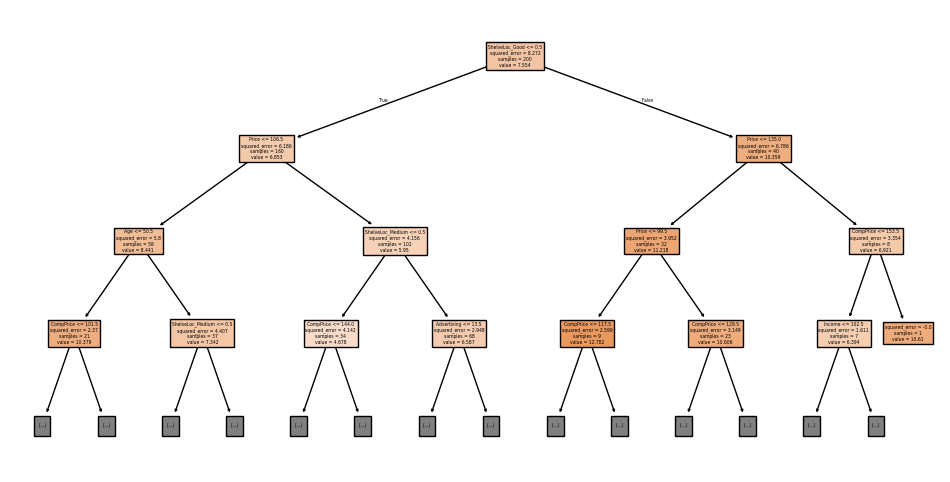

In [3]:
#Plot the tree
plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=X.columns, filled=True, max_depth=3)  # show top levels
plt.show()


(c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [4]:
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

kf = KFold(n_splits=10, shuffle=True, random_state=1)

cv_mse = []
for alpha in ccp_alphas:
    t = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha)
    scores = cross_val_score(
        t, X_train, y_train,
        cv=kf, scoring="neg_mean_squared_error"
    )
    cv_mse.append(-scores.mean())

best_alpha = ccp_alphas[np.argmin(cv_mse)]
print("Best ccp_alpha:", best_alpha)

pruned_tree = DecisionTreeRegressor(random_state=1, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)
print("Pruned tree test MSE:", mse_pruned)


Best ccp_alpha: 0.3152323885135033
Pruned tree test MSE: 5.105824732518417


(d) Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

In [8]:
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=1),
    n_estimators=500,
    bootstrap=True,
    max_features=1.0,
    random_state=1
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)
print("Bagging test MSE:", mse_bag)


Bagging test MSE: 2.852212935372007


In [9]:
fi_bag = np.mean([est.feature_importances_ for est in bag.estimators_], axis=0)
bag_importance = sorted(zip(X.columns, fi_bag), key=lambda x: x[1], reverse=True)
print("Bagging variable importance (top):")
for name, val in bag_importance[:8]:
    print(f"{name}: {val:.3f}")


Bagging variable importance (top):
Price: 0.298
ShelveLoc_Good: 0.231
Age: 0.107
CompPrice: 0.084
ShelveLoc_Medium: 0.084
Advertising: 0.058
Income: 0.052
Population: 0.046


(e) Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the
number of variables considered at each split, on the error rate obtained.

In [10]:
m_values = [2, 4, 6, 11]  # 11 = all features = bagging-like
rf_results = {}

for m in m_values:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        random_state=1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rf_results[m] = (mse_rf, rf.feature_importances_)

    print(f"Random forest (m={m}) test MSE: {mse_rf:.3f}")
    fi = sorted(zip(X.columns, rf.feature_importances_),
                key=lambda x: x[1], reverse=True)
    print("  Top variables:", [name for name, _ in fi[:5]])


Random forest (m=2) test MSE: 3.344
  Top variables: ['Price', 'ShelveLoc_Good', 'Age', 'CompPrice', 'Income']
Random forest (m=4) test MSE: 2.804
  Top variables: ['Price', 'ShelveLoc_Good', 'Age', 'CompPrice', 'Advertising']
Random forest (m=6) test MSE: 2.713
  Top variables: ['Price', 'ShelveLoc_Good', 'Age', 'CompPrice', 'Advertising']
Random forest (m=11) test MSE: 2.834
  Top variables: ['Price', 'ShelveLoc_Good', 'Age', 'CompPrice', 'ShelveLoc_Medium']
